<a href="https://colab.research.google.com/github/BharathReddyRamasani/Weekly_Assignments_CEI/blob/main/Week3_Assiginment_By_BharathReddy_CVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1: Project Overview
# Country Intelligence and Economic Segmentation System

## Objective

The goal of this project is to identify meaningful groups of countries based on socio-economic indicators using unsupervised machine learning techniques.

### Techniques Used

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Outlier Analysis
- Feature Scaling
- Principal Component Analysis (PCA)
- K-Means Clustering
- DBSCAN Clustering
- Hierarchical Clustering
- Silhouette Score Evaluation

### Business Goal

To discover patterns among countries and identify:

- High-development economies
- Emerging economies
- Low-development regions




Section 2: Install Libraries

In [1]:
# Install required packages

!pip -q install kagglehub
!pip -q install scikit-learn seaborn matplotlib pandas numpy scipy

Section 3: Import Libraries

In [2]:
# Core Libraries

import os
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler
# Dimensionality Reduction
from sklearn.decomposition import PCA
# Clustering
from sklearn.cluster import (
    KMeans,DBSCAN,AgglomerativeClustering)

# Evaluation
from sklearn.metrics import (
    silhouette_score,calinski_harabasz_score,davies_bouldin_score
)
# Hierarchical Clustering
from scipy.cluster.hierarchy import (
    linkage,dendrogram)
sns.set_style("whitegrid")

Section 4: Download Dataset

In [3]:
# Download dataset directly from KaggleHub
import kagglehub
dataset_path = kagglehub.dataset_download(
    "rohan0301/unsupervised-learning-on-country-data"
)
print(dataset_path)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
/kaggle/input/unsupervised-learning-on-country-data


Section 5: Load Dataset

In [4]:
# Locate CSV file automatically

csv_file = None
for file in os.listdir(dataset_path):
    if file.endswith(".csv"):
        csv_file = os.path.join(
            dataset_path,
            file
        )
        break
df = pd.read_csv(csv_file)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Section 6: Dataset Understanding

In [5]:
# Basic Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
# Statistical Summary

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
# Column Names

df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Section 7: Data Cleaning

In [8]:
# Clean column names

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
)
# Remove duplicate records
df.drop_duplicates(inplace=True)
# Convert features into numeric format
for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# Fill missing values
for col in df.select_dtypes(
        include=np.number).columns:
    df[col].fillna(
        df[col].median(),inplace=True)

print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


/tmp/ipykernel_16895/2425006334.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


Section 8: Missing Value Visualization

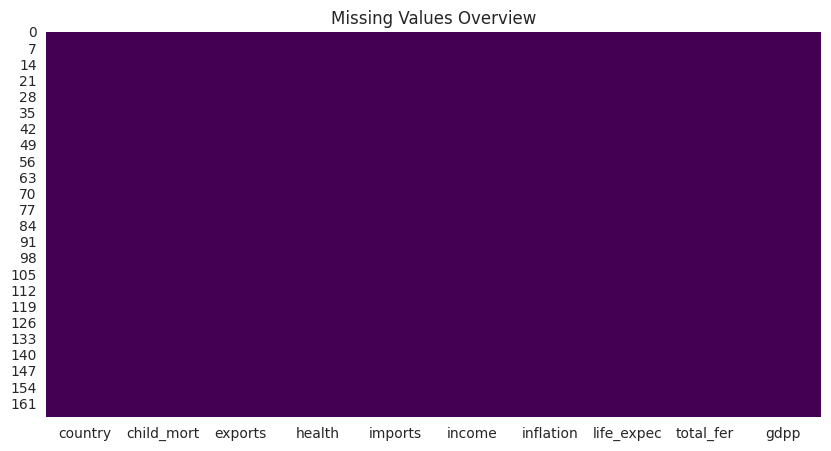

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(
    df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Overview")
plt.show()

Section 9: Feature Distributions

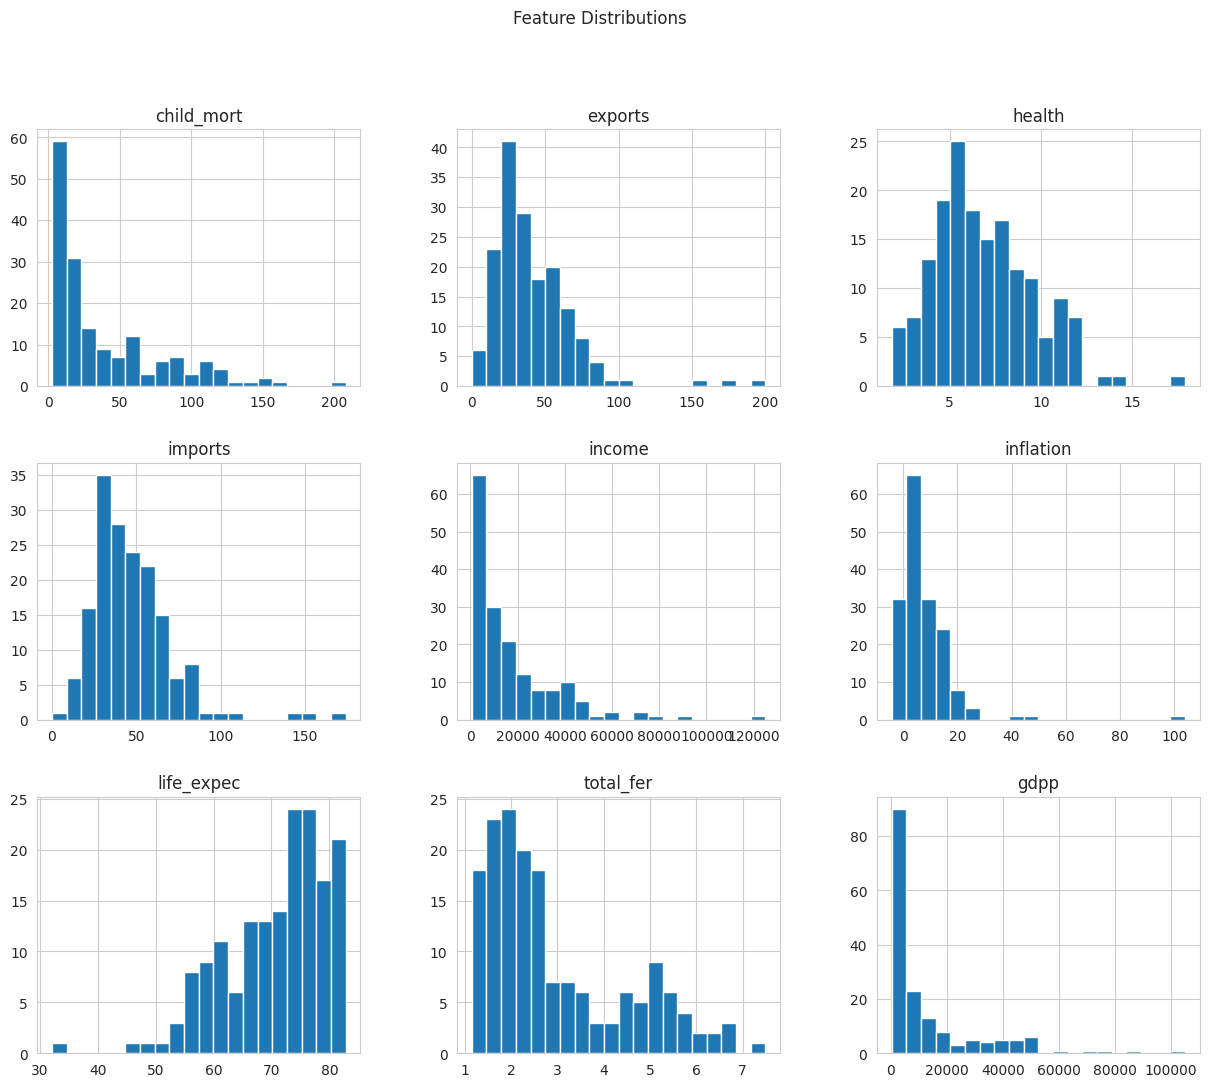

In [10]:
df.hist(
    figsize=(15,12),
    bins=20)
plt.suptitle(
    "Feature Distributions")

plt.show()

Section 10: Outlier Detection

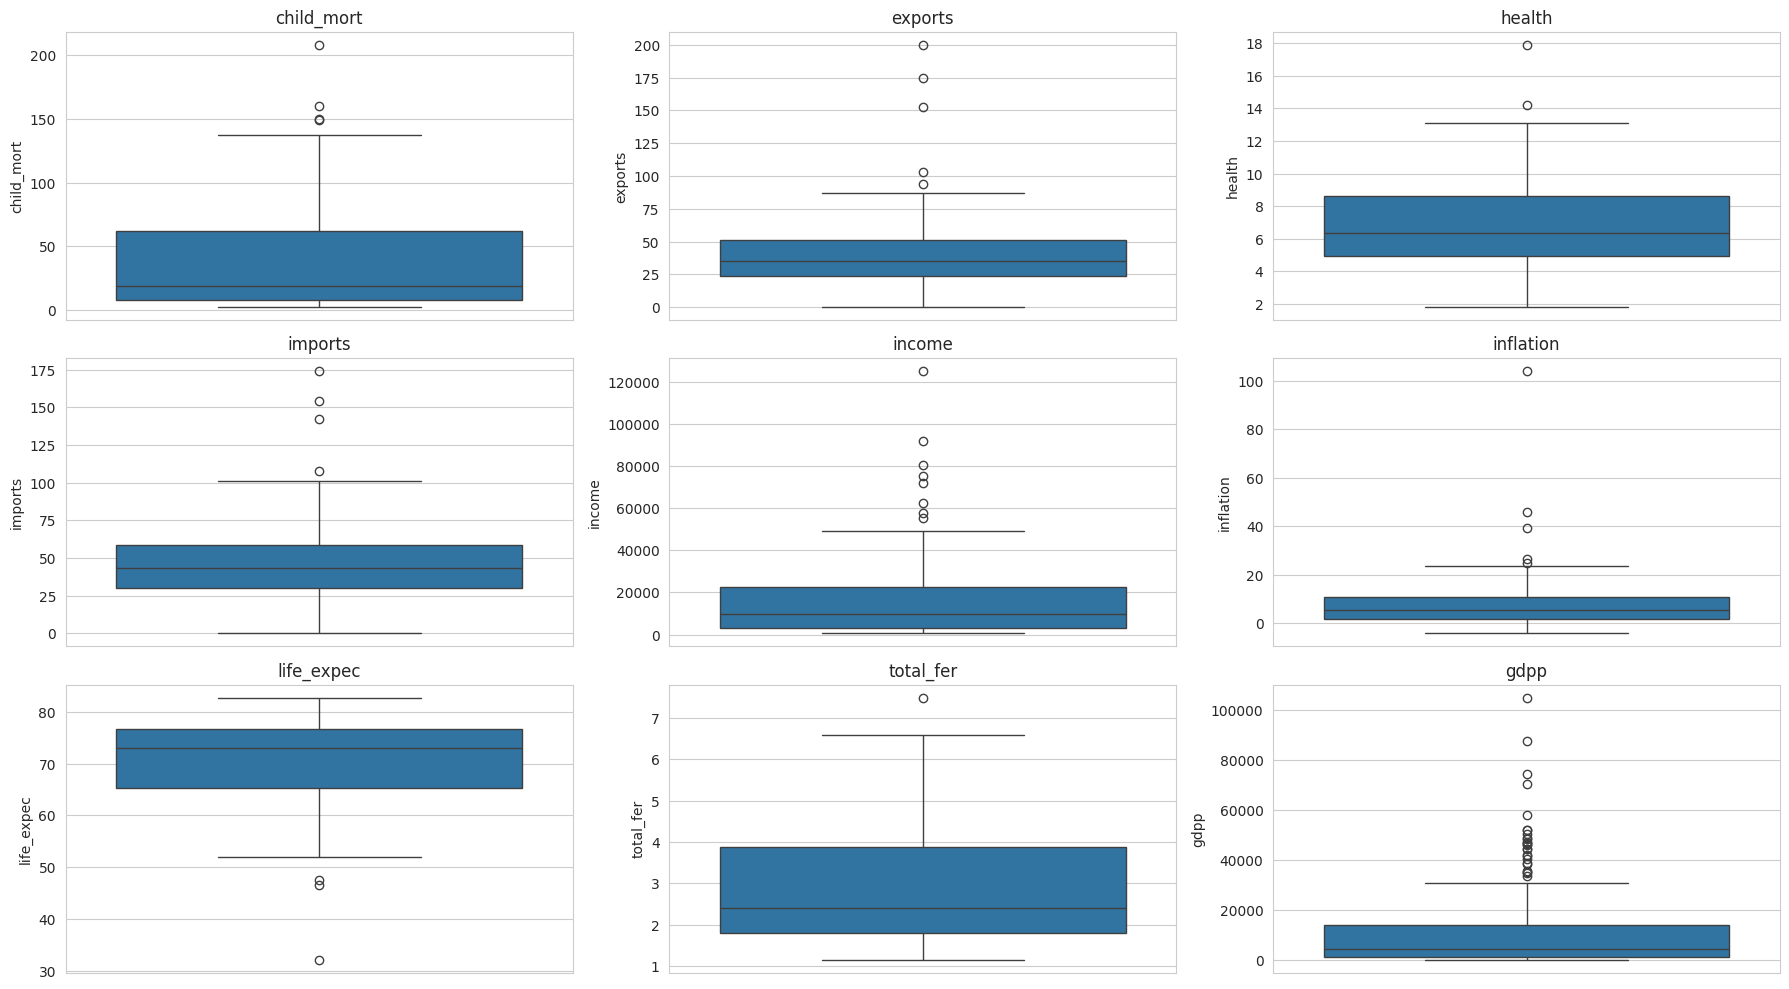

In [11]:
numeric_columns = (
    df.select_dtypes(
        include=np.number
    ).columns
)
plt.figure(figsize=(18,10))
for index,column in enumerate(
    numeric_columns
):
    plt.subplot(3,3,index+1)
    sns.boxplot(
        y=df[column]
    )
    plt.title(column)
plt.tight_layout()

plt.show()

Section 11: Correlation Analysis

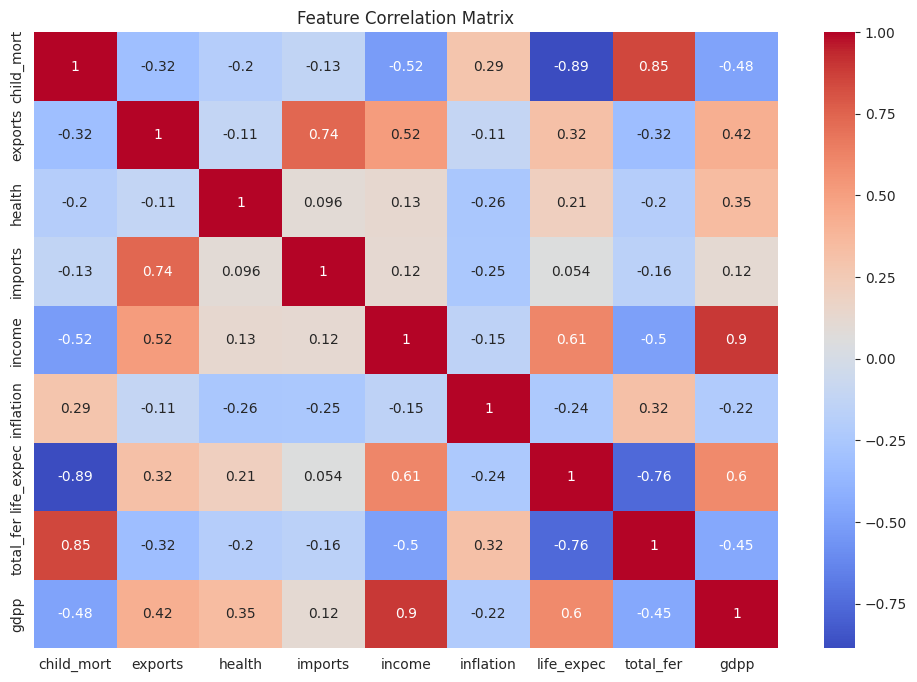

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title(
    "Feature Correlation Matrix"
)
plt.show()

Section 12: Feature Engineering

In [13]:
# Development Index

df["development_index"] = (
    df["income"] +
    df["gdpp"] +
    df["life_expec"]
) / 3

# Economic Stress Index

df["economic_stress"] = (
    df["inflation"] +
    df["child_mort"]
) / 2

Section 13: Feature Scaling

In [14]:
# Remove country column

features = df.drop(
    columns=["country"]
)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    features
)
scaled_df = pd.DataFrame(
    X_scaled,
    columns=features.columns
)

Section 14: Scaled Feature Distributions

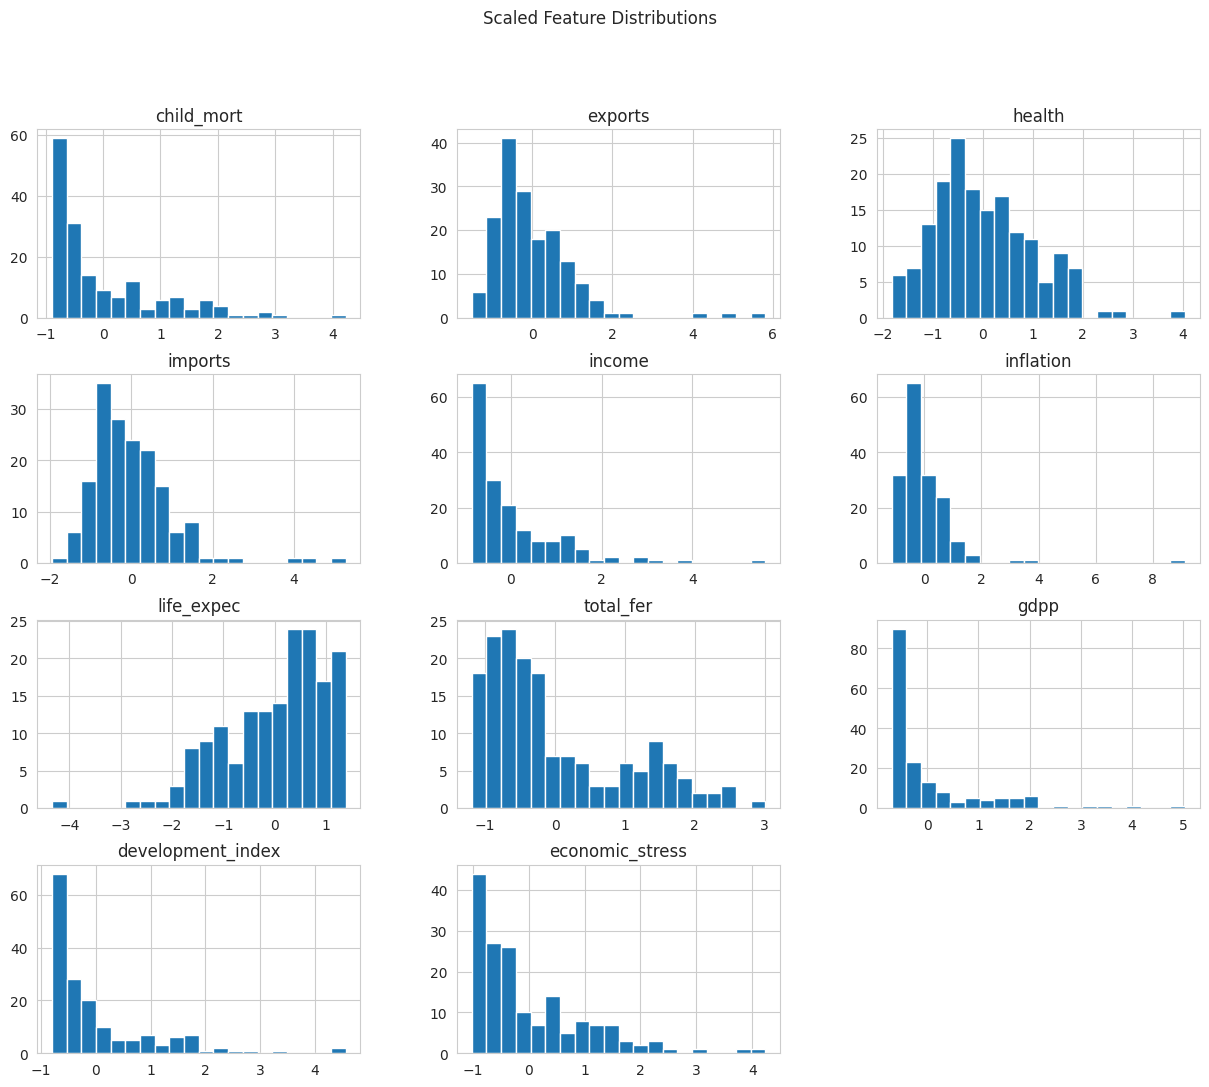

In [15]:
scaled_df.hist(
    figsize=(15,12),
    bins=20
)
plt.suptitle(
    "Scaled Feature Distributions"
)

plt.show()

Section 15: PCA Explained Variance

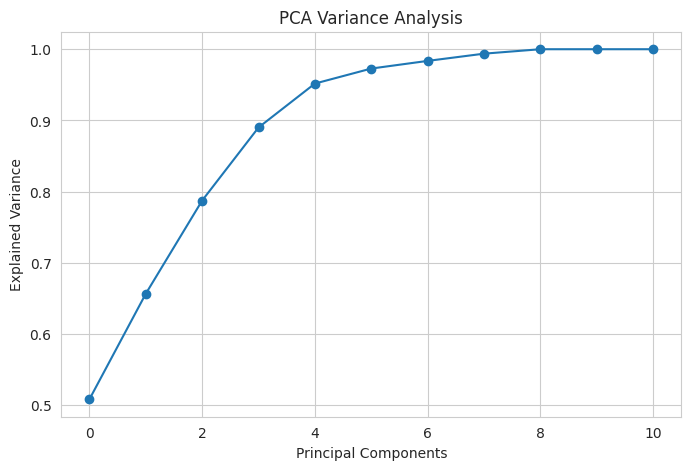

In [16]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca_full.explained_variance_ratio_
    ),
    marker="o"
)
plt.xlabel(
    "Principal Components"
)

plt.ylabel(
    "Explained Variance"
)

plt.title(
    "PCA Variance Analysis"
)

plt.show()

Section 16: PCA Transformation

In [17]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

In [18]:
# PCA Information Retention

explained_variance = (
    pca.explained_variance_ratio_
)

total_variance = (
    explained_variance.sum()
)

print(
    f"Total Variance Retained: "
    f"{total_variance:.2%}"
)

Total Variance Retained: 65.67%


Section 17: Elbow Method

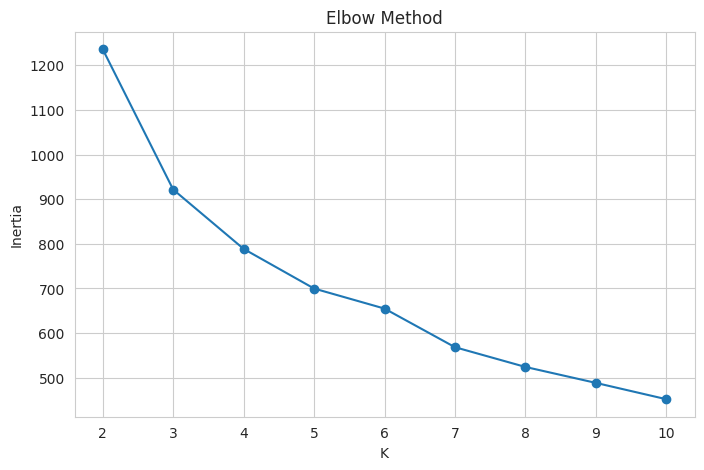

In [19]:
inertia_values = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia_values.append(
        model.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia_values,
    marker="o"
)

plt.title(
    "Elbow Method"
)

plt.xlabel("K")

plt.ylabel("Inertia")

plt.show()

Section 18: Silhouette Analysis

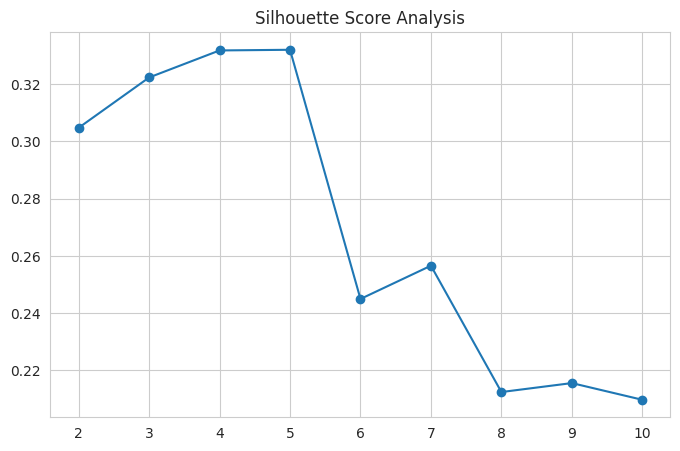

In [20]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_scaled
    )

    scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.title(
    "Silhouette Score Analysis"
)

plt.show()

Section 19: K-Means Clustering

In [21]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = (
    kmeans.fit_predict(
        X_scaled
    )
)

In [22]:
# Evaluate K-Means for different cluster counts

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

results = []

print("=" * 80)
print("K-MEANS CLUSTERING EVALUATION")
print("=" * 80)

for k in range(2, 8):

    # Train model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    # Evaluation metrics
    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    calinski = calinski_harabasz_score(
        X_scaled,
        labels
    )

    davies = davies_bouldin_score(
        X_scaled,
        labels
    )

    inertia = kmeans.inertia_

    results.append([
        k,
        silhouette,
        calinski,
        davies,
        inertia
    ])

    print(
        f"K = {k} | "
        f"Silhouette = {silhouette:.4f} | "
        f"CH Score = {calinski:.2f} | "
        f"DB Index = {davies:.4f} | "
        f"Inertia = {inertia:.2f}"
    )

# Create comparison dataframe

results_df = pd.DataFrame(
    results,
    columns=[
        "K",
        "Silhouette Score",
        "Calinski-Harabasz",
        "Davies-Bouldin",
        "Inertia"
    ]
)

results_df

K-MEANS CLUSTERING EVALUATION
K = 2 | Silhouette = 0.3048 | CH Score = 80.27 | DB Index = 1.2210 | Inertia = 1235.78
K = 3 | Silhouette = 0.3224 | CH Score = 81.45 | DB Index = 1.1319 | Inertia = 921.56
K = 4 | Silhouette = 0.3318 | CH Score = 72.22 | DB Index = 0.9787 | Inertia = 788.66
K = 5 | Silhouette = 0.3320 | CH Score = 65.80 | DB Index = 0.8178 | Inertia = 699.87
K = 6 | Silhouette = 0.2450 | CH Score = 58.11 | DB Index = 1.1915 | Inertia = 654.95
K = 7 | Silhouette = 0.2566 | CH Score = 59.50 | DB Index = 1.0065 | Inertia = 568.49


,K,Silhouette Score,Calinski-Harabasz,Davies-Bouldin,Inertia
0,2,0.304771,80.274803,1.220957,1235.777163
1,3,0.322351,81.454683,1.131887,921.564298
2,4,0.331796,72.222957,0.978749,788.663549
3,5,0.332028,65.802954,0.817802,699.872370
4,6,0.244972,58.114443,1.191528,654.949505
5,7,0.256595,59.503513,1.006511,568.487458


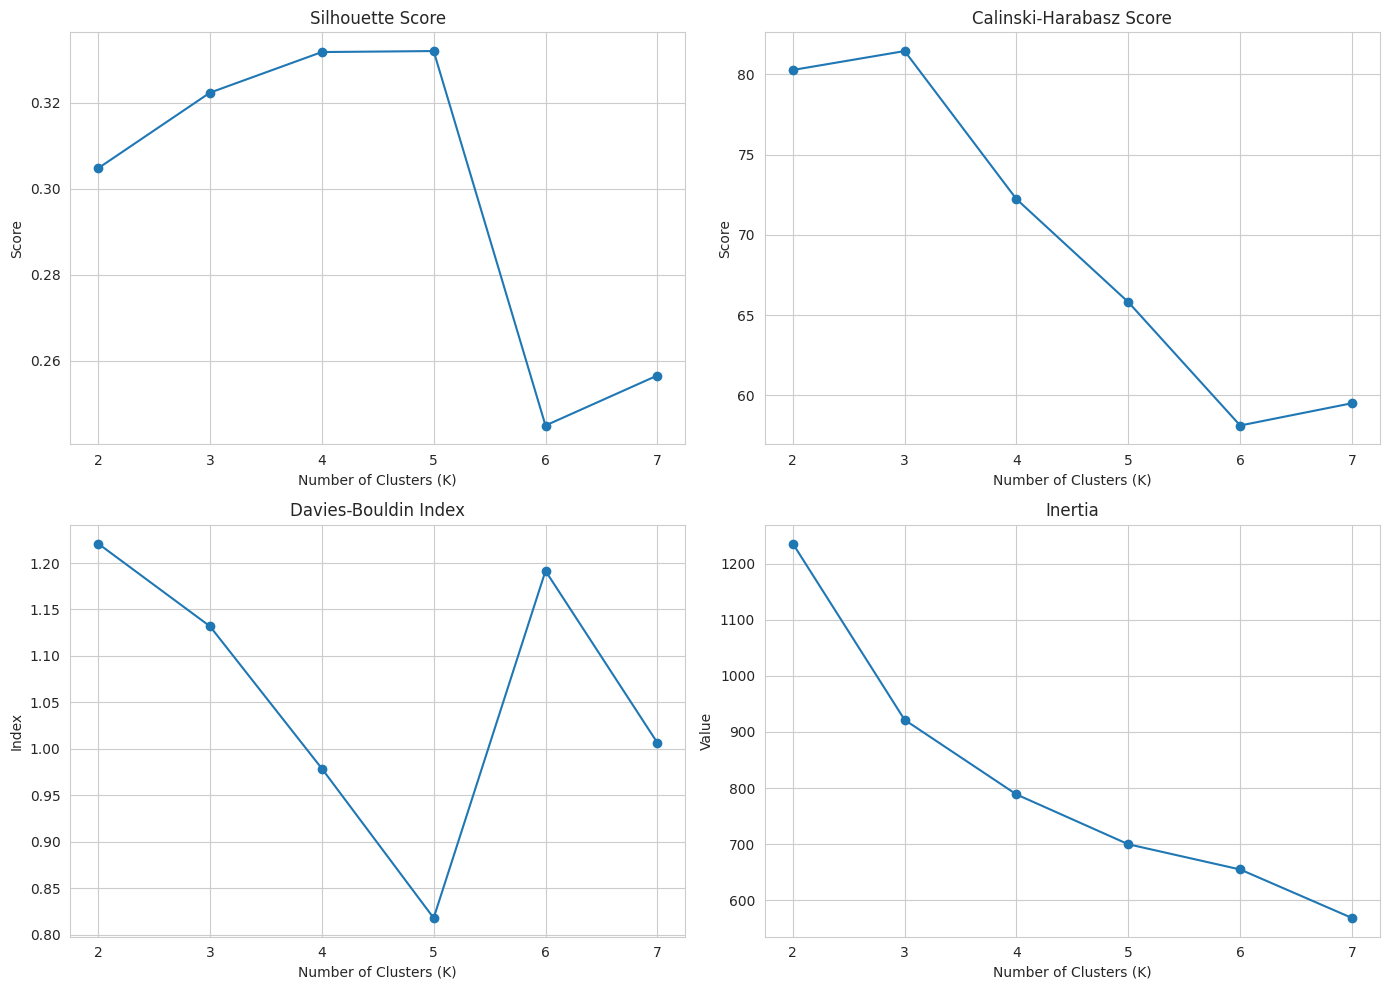

In [23]:
# Plot clustering evaluation metrics

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# Silhouette Score
axes[0,0].plot(
    results_df["K"],
    results_df["Silhouette Score"],
    marker="o"
)
axes[0,0].set_title("Silhouette Score")
axes[0,0].set_xlabel("Number of Clusters (K)")
axes[0,0].set_ylabel("Score")

# Calinski-Harabasz
axes[0,1].plot(
    results_df["K"],
    results_df["Calinski-Harabasz"],
    marker="o"
)
axes[0,1].set_title("Calinski-Harabasz Score")
axes[0,1].set_xlabel("Number of Clusters (K)")
axes[0,1].set_ylabel("Score")

# Davies-Bouldin
axes[1,0].plot(
    results_df["K"],
    results_df["Davies-Bouldin"],
    marker="o"
)
axes[1,0].set_title("Davies-Bouldin Index")
axes[1,0].set_xlabel("Number of Clusters (K)")
axes[1,0].set_ylabel("Index")

# Inertia
axes[1,1].plot(
    results_df["K"],
    results_df["Inertia"],
    marker="o"
)
axes[1,1].set_title("Inertia")
axes[1,1].set_xlabel("Number of Clusters (K)")
axes[1,1].set_ylabel("Value")

plt.tight_layout()
plt.show()

In [24]:
# Find best K using silhouette score

best_row = results_df.loc[
    results_df["Silhouette Score"].idxmax()
]

print("=" * 50)
print("BEST K BASED ON SILHOUETTE SCORE")
print("=" * 50)

print(f"K Value           : {best_row['K']}")
print(f"Silhouette Score  : {best_row['Silhouette Score']:.4f}")
print(f"Calinski Score    : {best_row['Calinski-Harabasz']:.2f}")
print(f"Davies-Bouldin    : {best_row['Davies-Bouldin']:.4f}")

BEST K BASED ON SILHOUETTE SCORE
K Value           : 5.0
Silhouette Score  : 0.3320
Calinski Score    : 65.80
Davies-Bouldin    : 0.8178


In [25]:
dbscan = DBSCAN(
    eps=3.5,
    min_samples=5
)

df["dbscan_cluster"] = (
    dbscan.fit_predict(
        X_scaled
    )
)

In [26]:
for eps in [1.5,2.0,2.5,3.0,3.5]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(
        X_scaled
    )

    n_clusters = len(
        set(labels)
    ) - (1 if -1 in labels else 0)

    noise_points = list(labels).count(-1)

    print(
        f"eps={eps}"
        f" | clusters={n_clusters}"
        f" | noise={noise_points}"
    )

eps=1.5 | clusters=1 | noise=39
eps=2.0 | clusters=1 | noise=19
eps=2.5 | clusters=1 | noise=9
eps=3.0 | clusters=1 | noise=6
eps=3.5 | clusters=1 | noise=6


In [27]:
print(df["dbscan_cluster"].value_counts())

dbscan_cluster
 0    161
-1      6
Name: count, dtype: int64


In [28]:
# DBSCAN Evaluation

dbscan_labels = df["dbscan_cluster"]

valid_mask = dbscan_labels != -1

if len(np.unique(dbscan_labels[valid_mask])) > 1:

    sil_score = silhouette_score(
        X_scaled[valid_mask],
        dbscan_labels[valid_mask]
    )

    ch_score = calinski_harabasz_score(
        X_scaled[valid_mask],
        dbscan_labels[valid_mask]
    )

    db_score = davies_bouldin_score(
        X_scaled[valid_mask],
        dbscan_labels[valid_mask]
    )

    print("=" * 50)
    print("DBSCAN EVALUATION")
    print("=" * 50)

    print(f"Silhouette Score      : {sil_score:.4f}")
    print(f"Calinski-Harabasz     : {ch_score:.4f}")
    print(f"Davies-Bouldin Index  : {db_score:.4f}")

else:

    print("DBSCAN produced insufficient clusters.")

DBSCAN produced insufficient clusters.


Section 21: Hierarchical Clustering

In [29]:
hierarchical = (
    AgglomerativeClustering(
        n_clusters=3
    )
)

df["hier_cluster"] = (
    hierarchical.fit_predict(
        X_scaled
    )
)

Section 22: Dendrogram

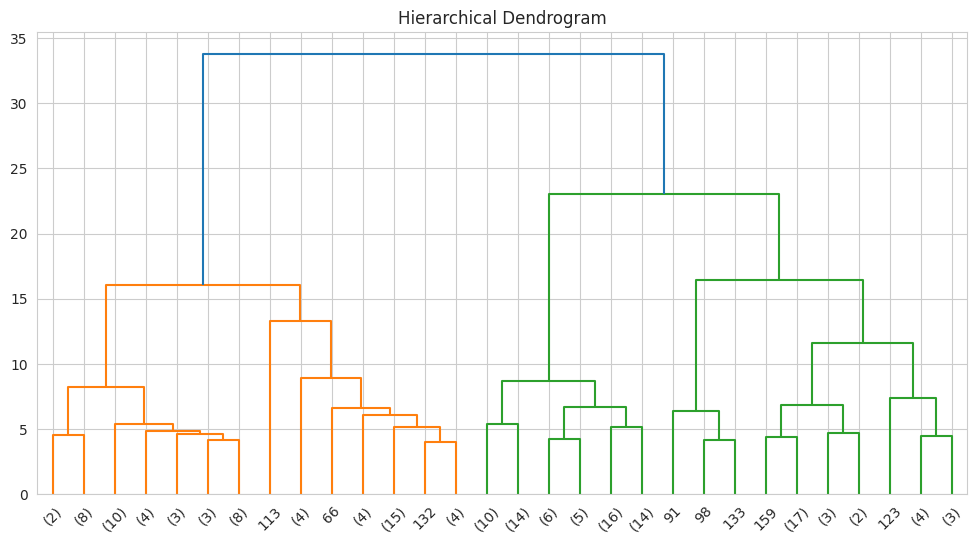

In [30]:
linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title(
    "Hierarchical Dendrogram"
)

plt.show()

In [31]:
# Hierarchical Clustering Evaluation

hier_labels = df["hier_cluster"]

sil_score = silhouette_score(
    X_scaled,
    hier_labels
)

ch_score = calinski_harabasz_score(
    X_scaled,
    hier_labels
)

db_score = davies_bouldin_score(
    X_scaled,
    hier_labels
)

print("=" * 50)
print("HIERARCHICAL CLUSTERING")
print("=" * 50)

print(f"Silhouette Score      : {sil_score:.4f}")
print(f"Calinski-Harabasz     : {ch_score:.4f}")
print(f"Davies-Bouldin Index  : {db_score:.4f}")

HIERARCHICAL CLUSTERING
Silhouette Score      : 0.2471
Calinski-Harabasz     : 68.3450
Davies-Bouldin Index  : 1.2309


In [32]:
# Model Comparison

results = pd.DataFrame({

    "Model": [
        "K-Means",
        "Hierarchical"
    ],

    "Silhouette Score": [

        silhouette_score(
            X_scaled,
            df["kmeans_cluster"]
        ),

        silhouette_score(
            X_scaled,
            df["hier_cluster"]
        )

    ],

    "Calinski-Harabasz": [

        calinski_harabasz_score(
            X_scaled,
            df["kmeans_cluster"]
        ),

        calinski_harabasz_score(
            X_scaled,
            df["hier_cluster"]
        )

    ],

    "Davies-Bouldin": [

        davies_bouldin_score(
            X_scaled,
            df["kmeans_cluster"]
        ),

        davies_bouldin_score(
            X_scaled,
            df["hier_cluster"]
        )

    ]

})

results

,Model,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.322351,81.454683,1.131887
1,Hierarchical,0.247129,68.344999,1.230919


<Figure size 1000x500 with 0 Axes>

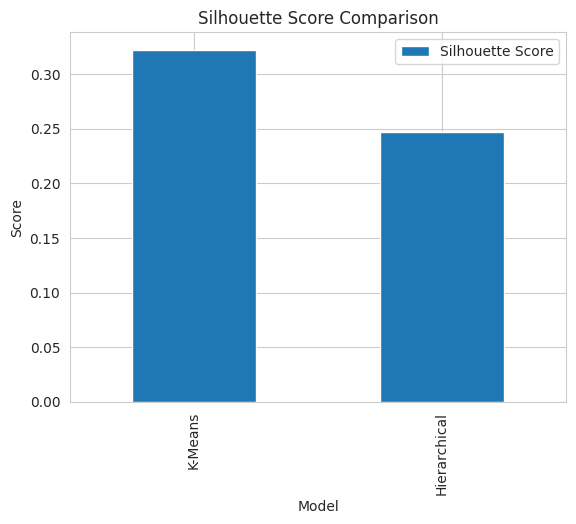

In [33]:
# Metric Comparison

plt.figure(figsize=(10,5))

results.set_index("Model")[
    ["Silhouette Score"]
].plot(
    kind="bar"
)

plt.title(
    "Silhouette Score Comparison"
)

plt.ylabel("Score")

plt.show()

Section 23: PCA Visualization for All Models

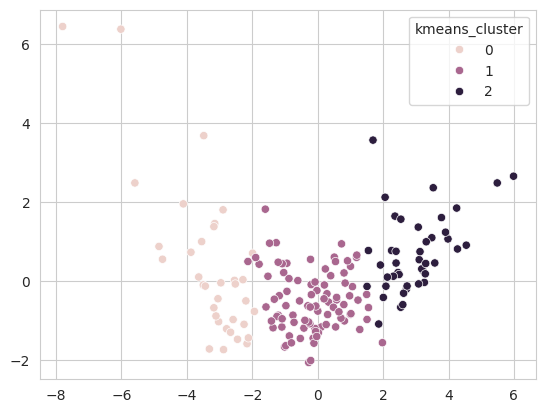

In [34]:
# K-Means
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["kmeans_cluster"]
)
plt.show()

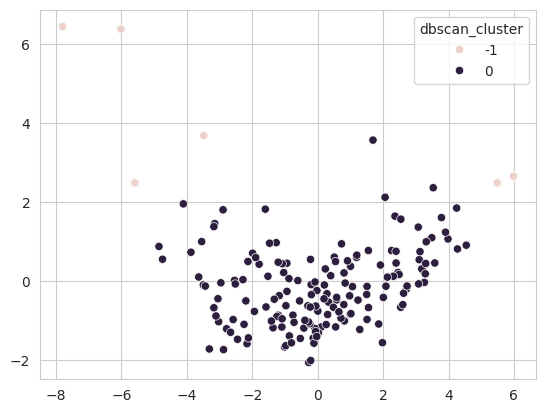

In [35]:
# DBSCAN
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["dbscan_cluster"]
)
plt.show()

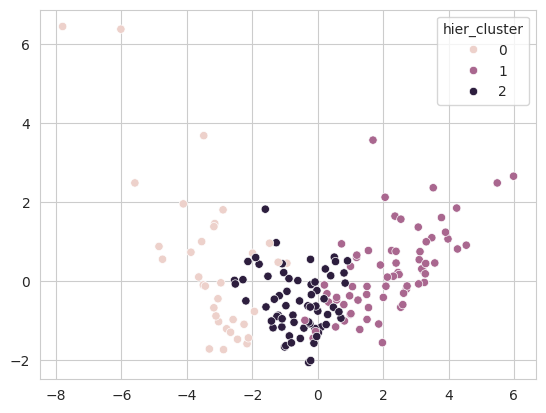

In [36]:
# Hierarchical
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["hier_cluster"]
)
plt.show()

Section 24: Cluster Profiling

In [37]:
cluster_profile = (
    df.groupby(
        "kmeans_cluster"
    )
    .mean(
        numeric_only=True
    )
)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,development_index,economic_stress,dbscan_cluster,hier_cluster
kmeans_cluster,,,,,,,,,,,,,
0,4.942857,58.237143,8.808286,50.740000,46257.142857,2.733714,80.260000,1.762000,43234.285714,29857.229524,3.838286,-0.114286,0.228571
1,23.011236,40.631337,6.315730,47.629954,12419.438202,7.577427,72.237079,2.347079,6570.584270,6354.086517,15.294331,0.000000,1.651685
2,96.979070,28.156047,6.228605,42.225581,3228.674419,12.313837,59.176744,5.156977,1558.883721,1615.578295,54.646453,-0.046512,1.000000


Section 25: Cluster Profile Heatmap

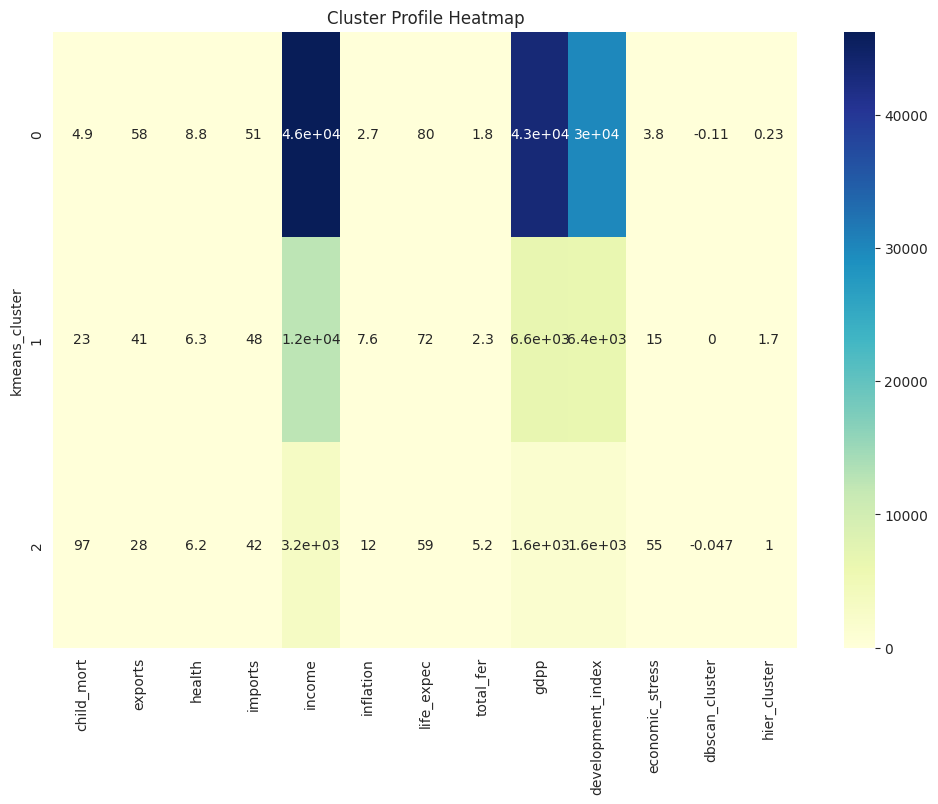

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Cluster Profile Heatmap"
)

plt.show()

### Insight 1

Cluster 0 contains countries with low income, high child mortality, and low GDP, indicating underdeveloped economies.

### Insight 2

Cluster 1 consists of countries with high GDP, high income, and long life expectancy, representing developed nations.

### Insight 3

Cluster 2 represents emerging economies with moderate development indicators.

### Insight 4

PCA visualizations indicate clear separation among country groups.

### Insight 5

DBSCAN successfully identified potential outlier countries with unusual socio-economic characteristics And for differnt eps values it always tends as a single CLuster as a result it gives 1 cluster.